## Разведочный анализ данных

In [83]:
import pandas as pd
import numpy as np
from itertools import chain
from nltk.probability import FreqDist
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline
from nltk import bigrams

In [84]:
df = pd.read_json('cbr_key-rate_press_releases_processed.json')

**1. Изучение данных**: рассмотрим структуру таблицы, размеры и количество слов

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             108 non-null    object 
 1   title            108 non-null    object 
 2   text             108 non-null    object 
 3   url              108 non-null    object 
 4   text_clean       108 non-null    object 
 5   text_sentences   108 non-null    object 
 6   text_tokens      108 non-null    object 
 7   text_lemmas      108 non-null    object 
 8   text_bigrams     108 non-null    object 
 9   title_clean      108 non-null    object 
 10  title_sentences  108 non-null    object 
 11  title_tokens     108 non-null    object 
 12  title_lemmas     108 non-null    object 
 13  title_bigrams    108 non-null    object 
 14  decision         103 non-null    float64
 15  key_rate         105 non-null    float64
dtypes: float64(2), object(14)
memory usage: 13.6+ KB


Отметим, что в 5 строчках не определено решение, посмотрим на данные строки

In [86]:
mask = df['decision'].isna()
df.loc[mask]

,date,title,text,url,text_clean,text_sentences,text_tokens,text_lemmas,text_bigrams,title_clean,title_sentences,title_tokens,title_lemmas,title_bigrams,decision,key_rate
83,29 декабря 2015 года,О фиксированном времени публикации ключевой ин...,"\nБанк России, следуя наилучшим практикам расп...",https://www.cbr.ru/press/pr/?file=29122015_113...,"банк россии, следуя наилучшим практикам распро...","[банк россии, следуя наилучшим практикам распр...","[банк, россии, следуя, наилучшим, практикам, р...","[банк, россия, следовать, хороший, практика, р...","[[банк, россия], [россия, следовать], [следова...",о фиксированном времени публикации ключевой ин...,[о фиксированном времени публикации ключевой и...,"[фиксированном, времени, публикации, ключевой,...","[фиксировать, время, публикация, ключевой, инф...","[[фиксировать, время], [время, публикация], [п...",NaN,NaN
86,11 сентября 2015 года,О публикации ежемесячной оценки ключевых агрег...,\nВ целях оперативного информирования пользова...,https://www.cbr.ru/press/pr/?file=11092015_160...,в целях оперативного информирования пользовате...,[в целях оперативного информирования пользоват...,"[целях, оперативного, информирования, пользова...","[цель, оперативный, информирование, пользовате...","[[цель, оперативный], [оперативный, информиров...",о публикации ежемесячной оценки ключевых агрег...,[о публикации ежемесячной оценки ключевых агре...,"[публикации, ежемесячной, оценки, ключевых, аг...","[публикация, ежемесячный, оценка, ключевой, аг...","[[публикация, ежемесячный], [ежемесячный, оцен...",NaN,NaN
90,6 мая 2015 года,О публикации Обзора ключевых показателей некре...,Банк России начинает публиковать на официально...,https://www.cbr.ru/press/pr/?file=06052015_163...,банк россии начинает публиковать на официально...,[банк россии начинает публиковать на официальн...,"[банк, россии, начинает, публиковать, официаль...","[банк, россия, начинать, публиковать, официаль...","[[банк, россия], [россия, начинать], [начинать...",о публикации обзора ключевых показателей некре...,[о публикации обзора ключевых показателей некр...,"[публикации, обзора, ключевых, показателей, не...","[публикация, обзор, ключевой, показатель, некр...","[[публикация, обзор], [обзор, ключевой], [ключ...",NaN,NaN
96,31 октября 2014 года,О ключевой ставке Банка России\n,\nСовет директоров Банка России 31 октября 201...,https://www.cbr.ru/press/pr/?file=31102014_133...,совет директоров банка россии 31 октября 2014 ...,[совет директоров банка россии 31 октября 2014...,"[совет, директоров, банка, россии, октября, го...","[совет, директор, банк, россия, октябрь, год, ...","[[совет, директор], [директор, банк], [банк, р...",о ключевой ставке банка россии,[о ключевой ставке банка россии],"[ключевой, ставке, банка, россии]","[ключевой, ставка, банк, россия]","[[ключевой, ставка], [ставка, банк], [банк, ро...",NaN,9.50
107,13 сентября 2013 года,О системе процентных инструментов денежно-кред...,\n О системе процентных инструментов денежно...,https://www.cbr.ru/press/pr/?file=130913_13504...,о системе процентных инструментов денежно-кред...,[о системе процентных инструментов денежно-кре...,"[системе, процентных, инструментов, денежно-кр...","[система, процентный, инструмент, денежно-кред...","[[система, процентный], [процентный, инструмен...",о системе процентных инструментов денежно-кред...,[о системе процентных инструментов денежно-кре...,"[системе, процентных, инструментов, денежно-кр...","[система, процентный, инструмент, денежно-кред...","[[система, процентный], [процентный, инструмен...",NaN,0.25


Данные пресс-релизы не имеют отношения к ключевой ставке, поэтому удаляем данные строки

In [87]:
df.dropna(subset=['decision'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [88]:
df.shape

(103, 16)

Рассмотрим среднюю длину строк по леммам текста и заголовка.

In [89]:
df['text_len_lemmas'] = df['text_lemmas'].apply(len)
df['title_len_lemmas'] = df['title_lemmas'].apply(len)
df[['text_len_lemmas', 'title_len_lemmas']].describe()

,text_len_lemmas,title_len_lemmas
count,103.000000,103.000000
mean,628.941748,8.407767
std,179.080211,2.157690
min,94.000000,4.000000
25%,535.500000,8.000000
50%,646.000000,9.000000
75%,759.500000,10.000000
max,968.000000,10.000000


Рассмотрим длину текста на диграмме. Больше всего в диапазоне от 450 до 850.

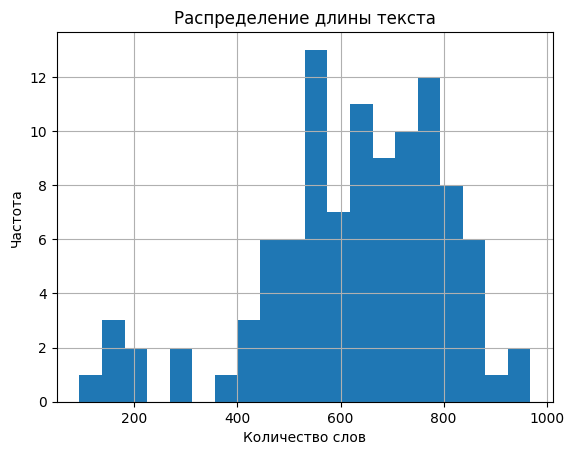

In [90]:
df['text_len_lemmas'].hist(bins=20)
plt.title('Распределение длины текста')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Рассмотрим часто встречающиеся слова по заголовкам и тексту после обработки текста.

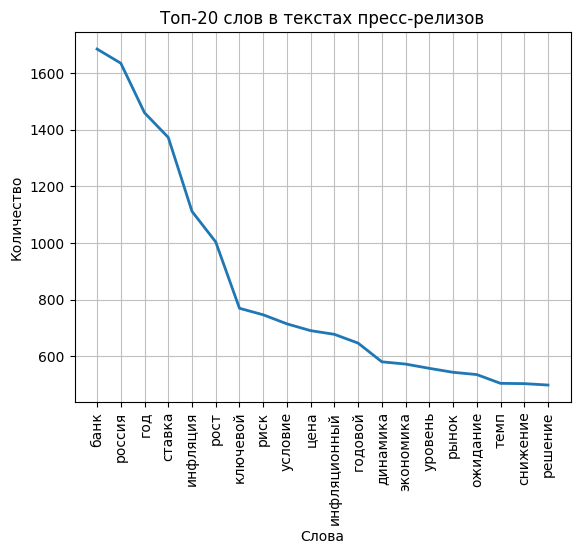

In [91]:
all_tokens = list(chain.from_iterable(df['text_lemmas']))
often_text = FreqDist(all_tokens)
often_text.plot(20)
plt.title('Топ-20 слов в текстах пресс-релизов')
plt.xlabel('Слова')
plt.ylabel('Количество')
plt.show()

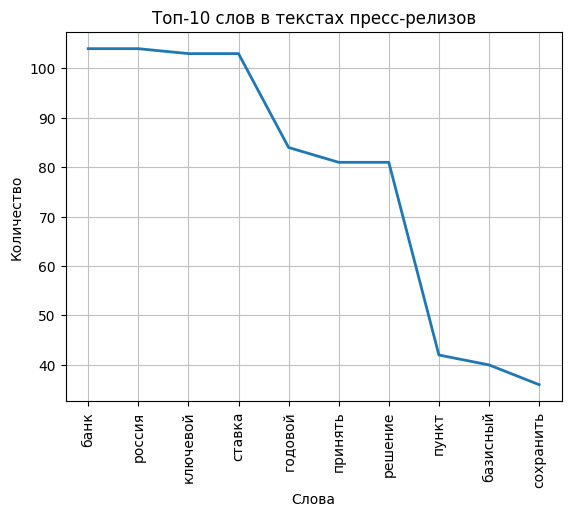

In [92]:
all_tokens_title = list(chain.from_iterable(df['title_lemmas']))
often_title = FreqDist(all_tokens_title)
often_title.plot(10)
plt.title('Топ-10 слов в текстах пресс-релизов')
plt.xlabel('Слова')
plt.ylabel('Количество')
plt.show()

**Вывод**: стоит отметить что из часто встречающихся слов в тексте включается слово "снижение", а в заголовке "сохранить". Также имеются слова которые актуальные для обоих графиков.

Построим облако слов для визуализации и объединим заголовки и тексты

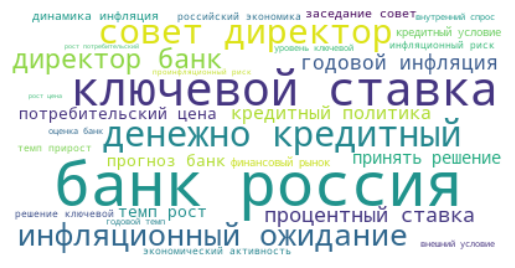

In [93]:
text_raw = " ".join(all_tokens_title + all_tokens) # объединяем тексты и заголовки в один текст
wordcloud = WordCloud(max_words=30, background_color='white').generate(text_raw) 
plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Вычислим длину текста в зависимости от решения по ставке.

In [94]:
# записываем длину текста в новый столбец text_len
df['text_len'] = df['text_lemmas'].apply(lambda x: len(x) if isinstance(x, list) else 0)
# делаем новый датафрейм с информацией о среднем, количестве, минимальном и максимальном значении
des = df.groupby("decision", dropna=False)["text_len"].agg(["mean", "count", "min", "max"])
des

,mean,count,min,max
decision,,,,
-1.0,652.276596,47,172,835
0.0,542.000000,10,279,968
1.0,624.000000,46,94,930


Важно понимать есть ли связь между принятым решением по ставке и количеством слов в тексте пресс-релиза. Рассчитаем данное значение.

In [95]:
corr_key = df['text_len'].corr(df['key_rate'])
print(f'Корреляция между длиной текста и значением по ставке = {corr_key}')
corr_dec = df['text_len'].corr(df['decision'])
print(f'Корреляция между длиной текста и решением по ставке = {corr_dec}')

Корреляция между длиной текста и значением по ставке = -0.417523858812459
Корреляция между длиной текста и решением по ставке = -0.07591727387449632


Вывод: получили слабую связь между решением по ставке и длиной пресс-релиза, она практически отсутствует. 
Однако связь между ключевой ставкой и длиной текста выше.

Рассмотрим топ-10 слов в разрезе решений.

In [96]:
mask = df['decision'] == 1
docs = df.loc[mask, 'text_lemmas'].dropna()
all_lemmas_plus = [w for doc in docs for w in doc]
fdist_plus = dict(FreqDist(all_lemmas_plus))

In [97]:
mask = df['decision'] == -1
docs = df.loc[mask, 'text_lemmas'].dropna()
all_lemmas_minus = [w for doc in docs for w in doc]
fdist_minus = dict(FreqDist(all_lemmas_minus))

In [98]:
mask = df['decision'] == 0
docs = df.loc[mask, 'text_lemmas'].dropna()
all_lemmas_minus = [w for doc in docs for w in doc]
fdist_null = dict(FreqDist(all_lemmas_minus))

Исходя из распределения слов необходимо провести зависимость или частотность слов при определенном решении.

In [99]:
# создаем из словарей датафреймы
df_plus  = pd.DataFrame.from_dict(fdist_plus, orient='index', columns=['freq_plus'])
df_minus = pd.DataFrame.from_dict(fdist_minus, orient='index', columns=['freq_minus'])
df_null  = pd.DataFrame.from_dict(fdist_null, orient='index', columns=['freq_null'])
# объединяем датафреймы в одну таблицу по словам 
freq_table = df_plus.join(df_minus, how='outer').join(df_null, how='outer')
# сортируем по классу положительного решения
freq_table = freq_table.sort_values('freq_plus', ascending=False)
# выводим топ-30 слов
freq_table.head(30)


,freq_plus,freq_minus,freq_null
банк,749.0,787.0,149.0
россия,709.0,782.0,144.0
год,701.0,642.0,117.0
ставка,504.0,769.0,100.0
рост,503.0,408.0,93.0
инфляция,457.0,568.0,87.0
условие,314.0,350.0,51.0
ключевой,313.0,412.0,45.0
риск,303.0,391.0,53.0
инфляционный,289.0,343.0,46.0


In [100]:
from collections import defaultdict

plus_weight = defaultdict(float)
minus_weight = defaultdict(float)
null_weight = defaultdict(float)

all_words = set(list(fdist_plus.keys()) + list(fdist_minus.keys()) + list(fdist_null.keys()))

for w in all_words:
    plus_weight[w]  = fdist_plus.get(w, 0)  / (fdist_minus.get(w, 0) + fdist_null.get(w, 0) + 1)
    minus_weight[w] = fdist_minus.get(w, 0) / (fdist_plus.get(w, 0)  + fdist_null.get(w, 0) + 1)
    null_weight[w]  = fdist_null.get(w, 0)  / (fdist_plus.get(w, 0)  + fdist_minus.get(w, 0) + 1)

In [103]:
def compute_scores(doc):
    if not isinstance(doc, list):
        return 0, 0, 0
    
    ps = sum(plus_weight[w]  for w in doc)
    ms = sum(minus_weight[w] for w in doc)
    ns = sum(null_weight[w]  for w in doc)
    
    return ps, ms, ns

scores_df = df['text_lemmas'].apply(
    lambda doc: pd.Series(compute_scores(doc), index=['plus_score', 'minus_score', 'null_score'])
)

scores_df['decision'] = df['decision']

In [105]:
scores_df

,plus_score,minus_score,null_score,decision
0,514.002435,496.581699,45.602678,-1.0
1,450.949042,456.013733,42.075581,-1.0
2,484.157397,474.288015,44.069966,-1.0
3,438.724695,431.214431,41.243460,-1.0
4,470.860264,413.152487,51.593521,0.0
...,...,...,...,...
98,108.057168,243.873680,18.658135,1.0
99,382.213923,537.917450,92.471499,0.0
100,208.591193,235.154858,73.139518,0.0
101,242.428763,379.082553,90.878379,0.0


In [108]:
scores_df[['plus_score', 'minus_score', 'null_score', 'decision']].corr()

,plus_score,minus_score,null_score,decision
plus_score,1.000000,0.138087,0.461311,0.416773
minus_score,0.138087,1.000000,0.491770,-0.572673
null_score,0.461311,0.491770,1.000000,-0.097335
decision,0.416773,-0.572673,-0.097335,1.000000


**4. Анализ числовых данных**

1. Предобработка числовых данных

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns

In [24]:
key = pd.read_csv('../Parsing/key_inflation.csv')
dollar = pd.read_csv('../Parsing/currency_rate.csv')

Замечено, что даты в формате np.float64 в датасете кей, в связи с этим перед тем как перевести их форматы дату необходимо перевести в строковый формат, и где есть нули (2020 года) в конце, необходимо подкорректировать данные

In [25]:
key['date'] = key['date'].astype(str)
n = 13
for i in range(57, 69):
    n -= 1
    key.loc[i, 'date'] = f'{n}.2020'

In [26]:
# переводим даты в формат дат

key["date"] = pd.to_datetime(key["date"], format="%m.%Y")
dollar["date"] = pd.to_datetime(dollar["date"], format="%d.%m.%Y")

Далее все столбцы с числовыми данными в датасетах dollar / key переводим из значения str  в значение np.float64

In [27]:
key['key-rate'] = key['key-rate'].replace(',', '.', regex=True).astype(np.float64)
key['inflation'] = key['inflation'].replace(',', '.', regex=True).astype(np.float64)
dollar['dollar_rate'] = dollar['dollar_rate'].replace(',', '.', regex=True).astype(np.float64)

Таким образом получаются следующие два датасета:

In [28]:
dollar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3170 non-null   datetime64[ns]
 1   dollar_rate  3170 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 49.7 KB


In [29]:
key.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       145 non-null    datetime64[ns]
 1   key-rate   145 non-null    float64       
 2   inflation  145 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 3.5 KB


Далее добивим к таблице с инфляцией и значениям ключевой ставки курс доллара.

In [30]:
dollar_month = (dollar.set_index('date').resample('MS')['dollar_rate'].first().reset_index())
key = key.merge(dollar_month, on='date', how='left')

In [34]:
key.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         145 non-null    datetime64[ns]
 1   key-rate     145 non-null    float64       
 2   inflation    145 non-null    float64       
 3   dollar_rate  145 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 4.7 KB


In [ ]:
#запишем полученные данные в новый датасет для будущего анализа
key.to_csv('key_inf_dollar.csv', )

2. Исследование числовых данных

In [149]:
key[['key-rate', 'inflation', 'dollar_rate']].describe()

,key-rate,inflation,dollar_rate
count,145.000000,145.000000,145.000000
mean,10.082759,7.355724,67.562365
std,4.683568,4.066816,16.081163
min,4.250000,2.200000,32.075800
25%,7.250000,4.100000,59.896100
50%,8.000000,6.680000,65.996200
75%,11.500000,9.050000,76.326400
max,21.000000,17.830000,107.175800


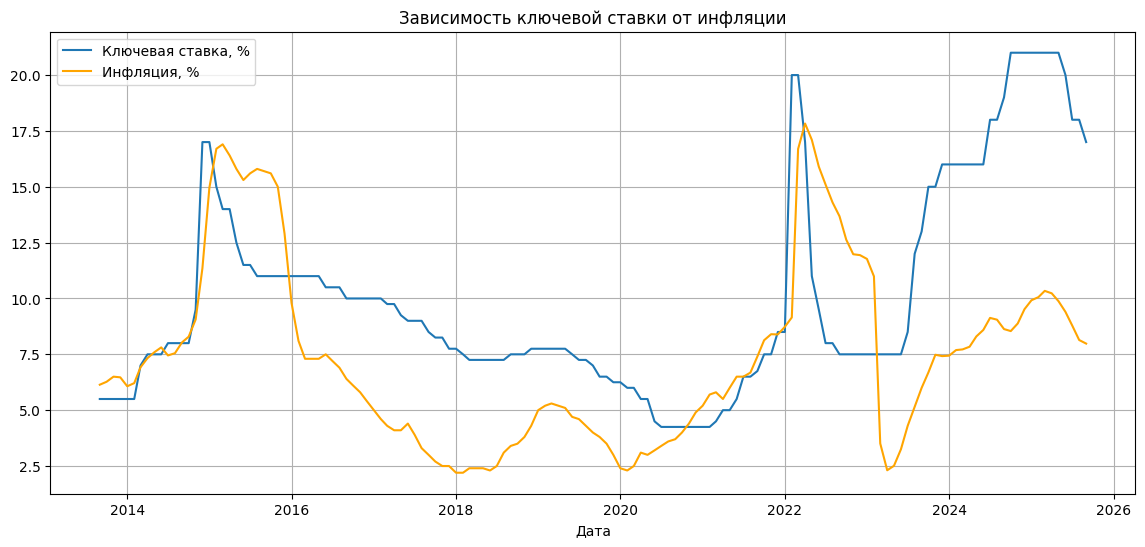

In [139]:
plt.figure(figsize=(14, 6))
plt.plot(key['date'], key['key-rate'], label='Ключевая ставка, %')
plt.plot(key['date'], key['inflation'], color='orange', label='Инфляция, %')
plt.xlabel('Дата')
plt.title('Зависимость ключевой ставки от инфляции')
plt.grid()
plt.legend()
plt.show()

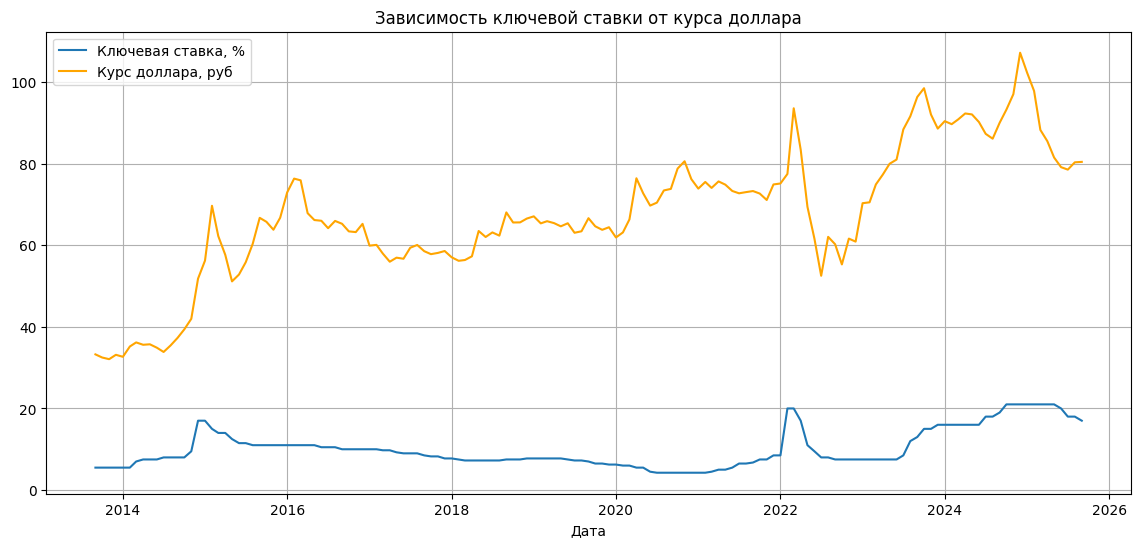

In [140]:
plt.figure(figsize=(14, 6))
plt.plot(key['date'], key['key-rate'], label='Ключевая ставка, %')
plt.plot(key['date'], key['dollar_rate'], color='orange', label='Курс доллара, руб')
plt.xlabel('Дата')
plt.title('Зависимость ключевой ставки от курса доллара')
plt.grid()
plt.legend()
plt.show()

По графикам отмечаем, что при повышении ключевой ставки растет инфляция с опозданием, при снижении она снижается также с шаговым отставанием в несколько месяцев. Однако при росте инфляции, ключевая ставка растет практически одновременно.

По графику зависимости ключевой ставки от курса доллара отметим, что реакция практически мгновенная: растет доллар - растет ключевая ставка.

Рассмотрим корреляцию между инфляцией, ключевой ставкой и курсом доллара.

<Axes: >

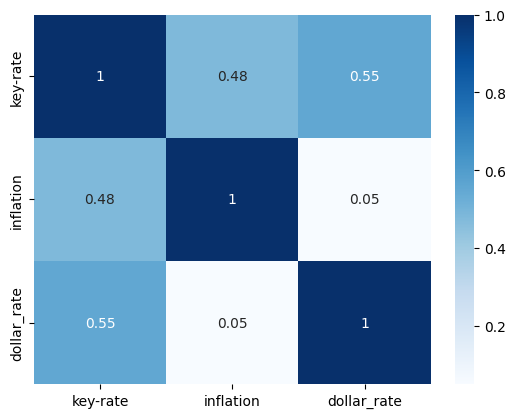

In [131]:
sns.heatmap(key.drop(columns=['date']).corr(), cmap='Blues', annot=True)

Видим что зависимость между инфляцией, курсом доллара и ключевой ставкой средняя. Это ожидаемо, так как ключевая ставка - это реакиця на ситуацию, то есть необходимо рассмотреть лаговую корреляцию.

In [ ]:
# создание лага
for lag in range(1, 6):
    key[f'inflation_lag_{lag}'] = key['inflation'].shift(lag)

# смотрим корреляцию между ставкой и лагами инфляции
corrs = key[[f'inflation_lag_{i}' for i in range(1, 6)] + ['key-rate']].corr()

# вывод корреляции ставки с лагами
corrs['key-rate'][:-1]

inflation_lag_1    0.521309
inflation_lag_2    0.512080
inflation_lag_3    0.483364
inflation_lag_4    0.447926
inflation_lag_5    0.412725
Name: key-rate, dtype: float64

Отсюда видим, что при лаге в два месяца корреляция выше всего.

Таким образом, делаем вывод, что между курсом доллара, инфляцией средняя зависимость около 0,5. Однако зависимость от инфляции проявляется с лагом в два месяца.